<a href="https://colab.research.google.com/github/mvgolubev99/kaggle-chemical-structure-and-logp/blob/dev/logp_baseline_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Downloads, installs, imports

In [ ]:
# download data
!mkdir -p ./data
!curl -L -o ./data/archive_logp.zip https://www.kaggle.com/api/v1/datasets/download/matthewmasters/chemical-structure-and-logp
!unzip ./data/archive_logp.zip -d ./data/
!rm ./data/archive_logp.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 81468  100 81468    0     0   163k      0 --:--:-- --:--:-- --:--:--  163k
Archive:  ./data/archive_logp.zip
  inflating: ./data/logP_dataset.csv  


In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 53.1 MB/s eta 0:00:00


bulk generators and Features morgan generator somehow are not available in google colab version of rdkit, though it is not outdated (2025.9.1).

Individual generators instead of bulk are used.

Deprecated GetMorganFingerprintAsBitVect instead of GetMorganGenerator GetFeaturesMorganGenerator is used.

So called "Pattern" and "Layered" are not used as they're abscent in colab rdkit.

In [ ]:
from pathlib import Path
import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors, MACCSkeys
from rdkit.Avalon import pyAvalonTools
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import root_mean_squared_error

from sklearn.dummy import DummyRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, Lasso

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # Disable RDKit logging to keep output clean

import warnings
# To ignore specific categories of warnings (e.g., DeprecationWarning):
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Fix seed

In [ ]:
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

# Data

In [ ]:
f = './data/logP_dataset.csv'
data = pd.read_csv(f, names = ['smiles', 'logp'])
data

,smiles,logp
0,C[C@H]([C@@H](C)Cl)Cl,2.3
1,C(C=CBr)N,0.3
2,CCC(CO)Br,1.3
3,[13CH3][13CH2][13CH2][13CH2][13CH2][13CH2]O,2.0
4,CCCOCCP,0.6
...,...,...
14605,CCC(SC)Br,2.7
14606,[2H]C([2H])([C@@H](CO)O)O,-1.8
14607,CC(C)NNC,0.4
14608,C[C@H]1CCC[CH]1,3.4


# Convert smiles to fingerprints

## FingerprintRepresentation classes

In [ ]:
# ------------------------------------------------------------------
# Base class
# ------------------------------------------------------------------

class BaseFingerprintRepresenation:
    __name__ = 'BaseFingerprintRepresenation'
    def __init__(self, smiles, *args, **kwargs):
        self.smiles = self._collect_smiles(smiles)
        self.args = args
        self.kwargs = kwargs
        self.mols = [Chem.MolFromSmiles(s) for s in self.smiles]

    def _collect_smiles(self, smiles):
        if isinstance(smiles, list):
            pass
        elif hasattr(smiles, 'to_list'):
            smiles = smiles.to_list()
        else:
            smiles = list(smiles)
        return smiles

    def mol_to_fp(self, mol):
        return np.zeros(1)

    def to_fps(self):
        fps = []
        for mol in self.mols:
            fp = self.mol_to_fp(mol)
            fps.append(fp)
        self.fps = np.array(fps)
        return self.fps

    def save_fps(self, savepath):
        if not hasattr(self, 'fps'):
            raise AttributeError(
                "There is no 'fps' attribute! Nothing to save."
            )
        if not isinstance(self.fps, np.ndarray):
            raise TypeError(
                f"fps attribute is of wrong type: {type(self.fps)}, "
                "but 'np.ndarray' is expected"
            )
        if savepath is None:
            raise ValueError("path should not be None!")
        np.save(savepath, self.fps)

# ------------------------------------------------------------------
# Morgan (ECFP)
# ------------------------------------------------------------------

class MorganFingerprint(BaseFingerprintRepresenation):
    def mol_to_fp(self, mol):
        # fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=self.kwargs.get('radius', 2), nBits=self.kwargs.get('nBits', 2048), useFeatures=False,)
        gen = GetMorganGenerator(
            radius=self.kwargs.get('radius', 2),
            fpSize=self.kwargs.get('fpSize', 2048),
        )
        fp = gen.GetFingerprint(mol)
        return np.array(fp, dtype=int)

# ------------------------------------------------------------------
# Features Morgan (FCFP)
# ------------------------------------------------------------------

class FeaturesMorganFingerprint(BaseFingerprintRepresenation):
    def mol_to_fp(self, mol):
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=self.kwargs.get('radius', 2),
            nBits=self.kwargs.get('nBits', 2048),
            useFeatures=True,
        )
        return np.array(fp, dtype=int)

# ------------------------------------------------------------------
# MACCS keys
# ------------------------------------------------------------------

class MACCSKeysFingerprint(BaseFingerprintRepresenation):
    def mol_to_fp(self, mol):
        fp = MACCSkeys.GenMACCSKeys(mol)
        return np.array(fp, dtype=int)

# ------------------------------------------------------------------
# RDKit fingerprint
# ------------------------------------------------------------------

class RDKitFingerprint(BaseFingerprintRepresenation):
    def mol_to_fp(self, mol):
        fp = Chem.RDKFingerprint(
            mol,
            minPath=self.kwargs.get('minPath', 1),
            maxPath=self.kwargs.get('maxPath', 7),
            fpSize=self.kwargs.get('fpSize', 2048),
            useHs=self.kwargs.get('useHs', True),
            branchedPaths=self.kwargs.get('branchedPaths', True)
        )
        return np.array(fp, dtype=int)

# ------------------------------------------------------------------
# Atom Pair (hashed)
# ------------------------------------------------------------------

class AtomPairFingerprint(BaseFingerprintRepresenation):
    def mol_to_fp(self, mol):
        fp = rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(
            mol,
            nBits=self.kwargs.get('nBits', 2048)
        )
        return np.array(fp, dtype=int)

# ------------------------------------------------------------------
# Topological Torsion (hashed)
# ------------------------------------------------------------------

class TopologicalTorsionFingerprint(BaseFingerprintRepresenation):
    def mol_to_fp(self, mol):
        fp = rdMolDescriptors.GetHashedTopologicalTorsionFingerprintAsBitVect(
            mol,
            nBits=self.kwargs.get('nBits', 2048)
        )
        return np.array(fp, dtype=int)

# ------------------------------------------------------------------
# Avalon fingerprint
# ------------------------------------------------------------------

class AvalonFingerprint(BaseFingerprintRepresenation):
    def mol_to_fp(self, mol):
        fp = pyAvalonTools.GetAvalonFP(
            mol,
            nBits=self.kwargs.get('nBits', 1024)
        )
        return np.array(fp, dtype=int)


# register all classes
FINGERPRINT_CLASSES = {
    "morgan": MorganFingerprint,
    'features_morgan': FeaturesMorganFingerprint,
    "maccs": MACCSKeysFingerprint,
    "rdkit": RDKitFingerprint,
    "atom_pair": AtomPairFingerprint,
    "topological_torsion": TopologicalTorsionFingerprint,
    "avalon": AvalonFingerprint,
}

def get_fingerprint_class(name: str):
    """Returns fingerprint class by its name"""
    name = name.lower()
    if name not in FINGERPRINT_CLASSES:
        raise ValueError(f"Unknown fingerprint type: {name}")
    return FINGERPRINT_CLASSES[name]


## Test

Lets test mol_to_fp method of fingerprint class on single molecule

In [ ]:
# Test molecule (benzene)
test_smiles = ["c1ccccc1"]

print("=== Testing mol_to_fp method in all fingerprint classes ===\n")

for name, fp_class in FINGERPRINT_CLASSES.items():
    print(f"Testing: {name}")
    try:
        # Create an instance of the fingerprint class
        fp_instance = fp_class(test_smiles)

        # Generate fingerprints
        fps = fp_instance.to_fps()

        # Check that the result is a numpy array
        if not isinstance(fps, np.ndarray):
            print(f"{name}: result is not np.ndarray, but {type(fps)}")
        elif fps.ndim != 2:
            print(f"{name}: result is np.ndarray but has unusual shape: {fps.shape}")
        else:
            print(f"{name}: OK, type {type(fps)}, shape {fps.shape}")
    except Exception as e:
        print(f"{name}:error during calculation — {type(e).__name__}: {e}")
    print()


=== Testing mol_to_fp method in all fingerprint classes ===

Testing: morgan
morgan: OK, type <class 'numpy.ndarray'>, shape (1, 2048)

Testing: features_morgan
features_morgan: OK, type <class 'numpy.ndarray'>, shape (1, 2048)

Testing: maccs
maccs: OK, type <class 'numpy.ndarray'>, shape (1, 167)

Testing: rdkit
rdkit: OK, type <class 'numpy.ndarray'>, shape (1, 2048)

Testing: atom_pair
atom_pair: OK, type <class 'numpy.ndarray'>, shape (1, 2048)

Testing: topological_torsion
topological_torsion: OK, type <class 'numpy.ndarray'>, shape (1, 2048)

Testing: avalon
avalon: OK, type <class 'numpy.ndarray'>, shape (1, 1024)



## Convert data

In [ ]:
# approx. 1 minute

print("=== Convert data from smiles to all fingerprints ===\n")

folder_to_save = Path("./data/")
if not folder_to_save.is_dir():
    raise FileNotFoundError(f"no such directory: {folder_to_save}")
print(f"\nsaving fingerprints to folder: \'{folder_to_save}'\n")

for k, (fp_name, fp_class) in enumerate(FINGERPRINT_CLASSES.items()):
    print(
        f"[{k+1}/{len(FINGERPRINT_CLASSES)}] "
        f"fp_name={fp_name}",
        end = ' ')
    savepath = folder_to_save / f"{fp_name}_from_smiles_X_data.npy"

    if savepath.is_file():
        print(f"\n      skipping {fp_name}, \'{savepath}\' already exists\n")
        continue

    fp_instance = fp_class(data['smiles'])
    fp_instance.to_fps()
    fp_instance.save_fps(savepath=savepath)

    print(
        f" fps.shape={fp_instance.fps.shape}"
        f"\n      saved as \'{savepath}\': {Path(savepath).is_file()}\n"
    )

=== Convert data from smiles to all fingerprints ===


saving fingerprints to folder: 'data'

[1/7] fp_name=morgan  fps.shape=(14610, 2048)
      saved as 'data/morgan_from_smiles_X_data.npy': True

[2/7] fp_name=features_morgan  fps.shape=(14610, 2048)
      saved as 'data/features_morgan_from_smiles_X_data.npy': True

[3/7] fp_name=maccs  fps.shape=(14610, 167)
      saved as 'data/maccs_from_smiles_X_data.npy': True

[4/7] fp_name=rdkit  fps.shape=(14610, 2048)
      saved as 'data/rdkit_from_smiles_X_data.npy': True

[5/7] fp_name=atom_pair  fps.shape=(14610, 2048)
      saved as 'data/atom_pair_from_smiles_X_data.npy': True

[6/7] fp_name=topological_torsion  fps.shape=(14610, 2048)
      saved as 'data/topological_torsion_from_smiles_X_data.npy': True

[7/7] fp_name=avalon  fps.shape=(14610, 1024)
      saved as 'data/avalon_from_smiles_X_data.npy': True



# Split data

Here we just use random splitting of data. But in general, we should pay attention to splitting method because simple random splitting may lead to overestimation of model quality due to data leakage.

In previous version (which was generated by chatgpt using one prompt, lol) i did not notice signigicant differences between butina split and random split. Murcko scaffold split cannot be applied here, because most of molecules from this dataset will be assigned with empty scaffold.

split indices and then access data by them

In [ ]:
data_ids =  data.index.to_numpy()
train_ids, test_ids = train_test_split(data_ids, random_state=42)
train_ids, val_ids = train_test_split(train_ids, random_state=42)

In [ ]:
print(
    f"train set size:\t{len(train_ids)}\n"
    f"val set size:\t{len(val_ids)}\n"
    f"test set size:\t{len(test_ids)}"
)

train set size:	8217
val set size:	2740
test set size:	3653


In [ ]:
y_train = data['logp'].iloc[train_ids].values.reshape(-1, 1)
y_val = data['logp'].iloc[val_ids].values.reshape(-1, 1)

y_train, y_val, y_test = [
    data['logp'].iloc[ids].values.reshape(-1, 1) for ids in [train_ids, val_ids, test_ids]
]

In [ ]:
len(y_train), len(y_val), len(y_test)

(8217, 2740, 3653)

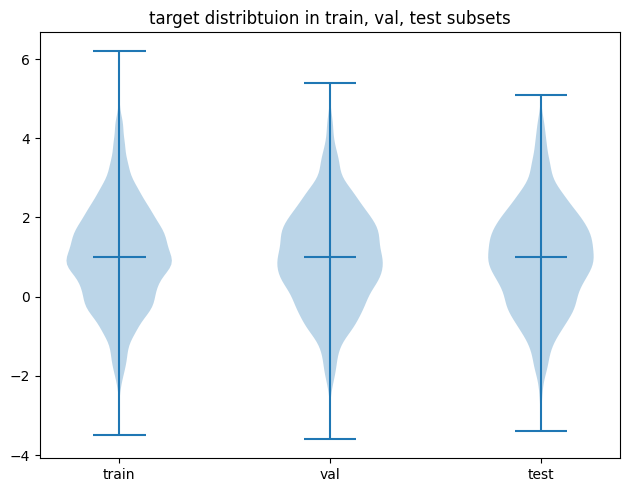

In [ ]:
def plot_target_distributions(target, **ids):
    """
    Draws violin plots comparing target distributions for each fold's train/test
    subsets and the final test set.
    """
    #plt.figure(figsize=(4*len(ids),len(ids)))
    plt.figure()
    data = []
    labels = []
    for name, data_ids in ids.items():
        data.append(target.iloc[data_ids].values)
        labels.append(name)

    plt.violinplot(data, showmedians=True)
    plt.xticks(range(1, len(ids) + 1), labels=ids.keys())
    #plt.xticklabels(ids.keys(), rotation=20)
    plt.tight_layout()
    plt.title(f"target distribtuion in {', '.join(ids.keys())} subsets")
    plt.show()


plot_target_distributions(
    target = data['logp'],
    train=train_ids,
    val=val_ids,
    test=test_ids,
)

In [ ]:
def make_k_fold_split_ids(
    data_ids,
    n_splits=5,
    random_state=42,
    shuffle=True,
    ):
    """
    This function returns list of folds, where
    each fold contains indices of 'train' and 'test' subset.
    """
    splitter = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)
    folds_ids = []
    # No list comprehension for better readability.
    # Do not be confused! Unlike train_test_split,
    # KFold.split() method return indices of 'train' and 'test',
    # not the actual data
    for train_ids, test_ids in splitter.split(data_ids):
        fold_ids = {
            'train': data_ids[train_ids],
            'test': data_ids[test_ids],
        }
        folds_ids.append(fold_ids)
    return folds_ids

folds_ids = make_k_fold_split_ids(train_ids)

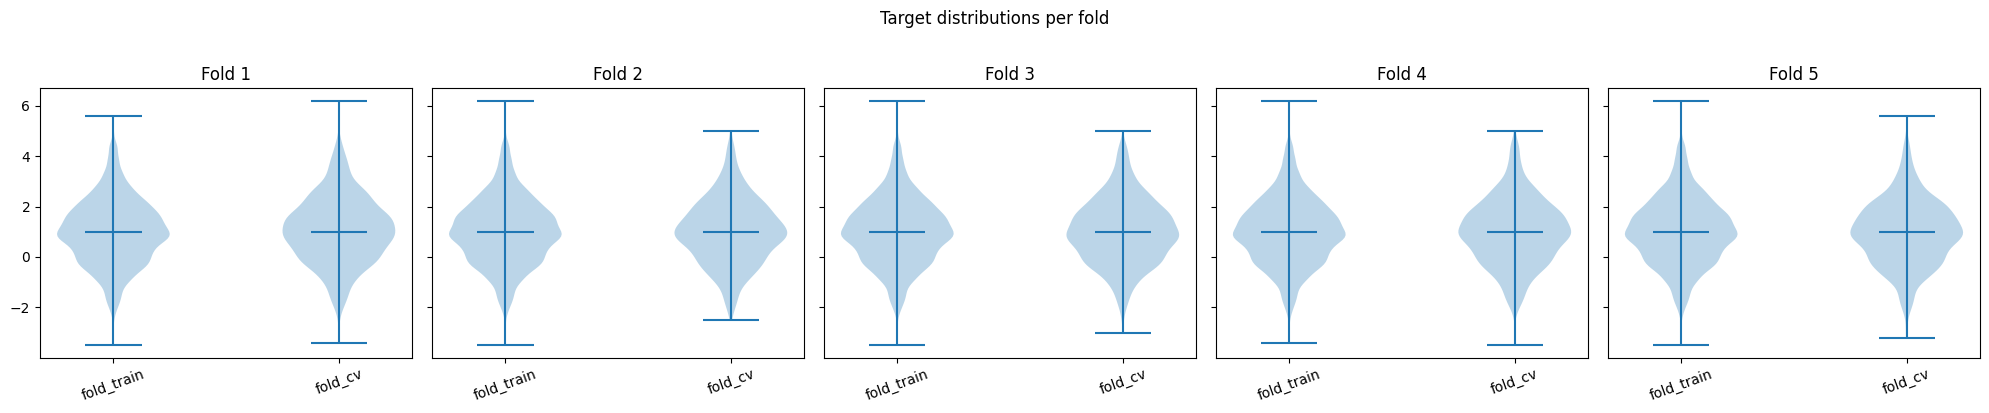

In [ ]:
def plot_target_distributions_cv(target, folds_ids):
    """
    Draws violin plots comparing target distributions for each fold's train/test
    subsets and the final test set.
    """
    n_splits = len(folds_ids)
    fig, axes = plt.subplots(1, n_splits, figsize=(4 * n_splits, 4), sharey=True)

    if n_splits == 1:
        axes = [axes]

    for i, fold in enumerate(folds_ids):
        data = [
            target.iloc[fold['train']],
            target.iloc[fold['test']],
        ]
        labels = ['fold_train', 'fold_cv']
        axes[i].violinplot(data, showmedians=True)
        axes[i].set_xticks(range(1, len(labels) + 1))
        axes[i].set_xticklabels(labels, rotation=20)
        axes[i].set_title(f'Fold {i+1}')

    fig.suptitle('Target distributions per fold', y=1.02)
    plt.tight_layout()
    plt.show()


plot_target_distributions_cv(data['logp'], folds_ids)

Also, attention should be paid to target disbalance.

Luckily enough, random splitting of this exact dataset does not lead to any significant target disbalance.

But scaffold aware (or any group aware) splitting methods could lead to target disbalance.

# Pipeline

In [ ]:
class TransformedTargetRegressor_with_custom_metric(TransformedTargetRegressor):
    def __init__(
            self,
            regressor=None,
            transformer=None,
            func=None,
            inverse_func=None,
            check_inverse=True,
            score_metric='root_mean_squared_error',
            #**kwargs,
        ):
        super().__init__(
            regressor=regressor,
            transformer=transformer,
            func=func,
            inverse_func=inverse_func,
            check_inverse=check_inverse,
            #**kwargs,
        )
        self.score_metric = score_metric

    def _get_scoring_func_from_score_metric(self):
        if callable(self.score_metric):
            return self.score_metric

        if not isinstance(self.score_metric, str):
            raise TypeError(f"score_metric expected to be string or callable!")

        if self.score_metric == 'root_mean_squared_error':
            from sklearn.metrics import root_mean_squared_error
            return root_mean_squared_error

        if self.score_metric == 'r2_score':
            from sklearn.metrics import r2_score
            return r2_score

        if self.score_metric == 'mean_absolute_error':
            from sklearn.metrics import mean_absolute_error
            return mean_absolute_error

        # there might be other metrics
        # ...

        # raise error if score_metric is not callable and was not found anywhere
        raise ValueError(
            f"score_metric={self.score_metric} is not a valid scoring value"
        )

    def score(
            self,
            X,
            y,
            **kwargs,
        ):
        scoring = self._get_scoring_func_from_score_metric()
        y_pred = self.predict(X)
        score = scoring(y, y_pred, **kwargs)
        # r2_score should be maximized,
        # rmse, mae should be minimized
        if self.score_metric not in ['r2_score']:
            score *= -1
        return score

In [ ]:
from sklearn.base import BaseEstimator

"""
class BaseTransform(BaseEstimator):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X

    def fit_transform(self, X, y=None):
        self.fit(X=X, y=y)
        return self.transform(X=X)

    def inverse_transform(self, X):
        return X
"""

class FpFromFileTransform(BaseEstimator):
    def __init__(self, path=None, cash_fp=True):
        self.path = path
        self.cash_fp=cash_fp

    def fit(self, X, y=None):
        self.X_fp_data = np.load(self.path) if self.cash_fp else None
        return self

    def transform(self, X):
        if self.X_fp_data is None:
            X_fp_data = np.load(self.path)
        else:
            X_fp_data = self.X_fp_data
        return X_fp_data[X]

In [ ]:
def construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
        regressor__fp_transform__path,
        regressor__fp_transform__cash_fp=True,
        regressor__model=LGBMRegressor(random_state=42, verbose=-1),
        transformer=StandardScaler(), # transformer for y
    ):
    if not Path(regressor__fp_transform__path).is_file():
        raise ValueError(f"Path {regressor__fp_transform__path} do not exist")

    regressor = Pipeline(
        steps=[
            ('fp_transform', FpFromFileTransform(
                path=regressor__fp_transform__path,
                cash_fp=regressor__fp_transform__cash_fp,
                )),
            ('model', regressor__model),
        ]
    )

    pipe = TransformedTargetRegressor_with_custom_metric(
        regressor=regressor,
        transformer=transformer,
    )
    return pipe

In [ ]:
print("DummyRegressor")
pipe = construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
    '/content/data/morgan_from_smiles_X_data.npy',
    regressor__model = DummyRegressor(strategy='median'),
)

pipe.fit(X=train_ids, y=y_train)
val_score = pipe.score(X=val_ids, y=y_val)
print(f"{pipe.score_metric} on validation: {abs(val_score)}")

DummyRegressor
root_mean_squared_error on validation: 1.2790921164387523


In [ ]:
pipe = construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
    '/content/data/morgan_from_smiles_X_data.npy',
)

param_grid = {
    'regressor__fp_transform__path': glob.glob("./data/*X_data.npy"),
    'regressor__model': [
        DummyRegressor(strategy='median'),
        LGBMRegressor(random_state=42),
        XGBRegressor(random_state=42),
        Ridge(random_state=42),
        Lasso(random_state=42),
    ],
}

gscv = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=KFold(n_splits=5, random_state=42, shuffle=True),
)

In [ ]:
gscv.fit(X=train_ids, y=y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor_with_custom_metric(regressor=Pipeline(steps=[('fp_transform',
                                                                                                FpFromFileTransform(path='/content/data/morgan_from_smiles_X_data.npy')),
                                                                                               ('model',
                                                                                                LGBMRegressor(random_state=42,
                                                                                                              verbose=-1))]),
                                                                     transformer=StandardScaler()),
             param_grid={'regressor__fp_trans...
                                                           importance_type=None,
                                                           interaction_constraints=None,
                                                           learning_rate=None,
                                                           max_bin=None,
                                                           max_cat_threshold=None,
                                                           max_cat_to_onehot=None,
                                                           max_delta_step=None,
                                                           max_depth=None,
                                                           max_leaves=None,
                                                           min_child_weight=None,
                                                           missing=nan,
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=None,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...),
                                              Ridge(random_state=42),
                                              Lasso(random_state=42)]})

In [ ]:
gscv.cv_results_

{'mean_fit_time': array([0.41494212, 0.70740871, 3.584202  , 1.54595399, 0.57759466,
        0.14557018, 0.69634562, 3.18340187, 1.84108438, 0.48960505,
        0.38893366, 1.68133769, 3.40104747, 1.80919452, 0.5065414 ,
        0.03092923, 0.22555919, 0.76389828, 0.16147184, 0.04768023,
        0.32378125, 1.12780695, 2.0600966 , 0.54528346, 0.29488177,
        0.39328637, 0.55179567, 3.22116957, 1.89284644, 0.54997215,
        0.38327856, 0.51425829, 3.80092516, 1.80135021, 0.57324677]),
 'std_fit_time': array([0.52281725, 0.03537136, 0.76418622, 0.0578429 , 0.0229354 ,
        0.0209953 , 0.0306883 , 0.47913242, 0.50803279, 0.01306363,
        0.50356172, 0.32253552, 0.74207432, 0.3682912 , 0.02230548,
        0.03739817, 0.00893727, 0.47250229, 0.07084887, 0.00339749,
        0.34198608, 0.46451532, 0.81833606, 0.04765119, 0.01794834,
        0.48128044, 0.1079044 , 0.73692699, 0.37636809, 0.03172439,
        0.46561086, 0.01497707, 1.67243819, 0.48638086, 0.05012975]),
 'mean_scor

In [ ]:
gscv.best_params_

{'regressor__fp_transform__path': './data/maccs_from_smiles_X_data.npy',
 'regressor__model': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)}

In [ ]:
gscv.best_score_

np.float64(-0.3170670159921186)